In [9]:
from tqdm import tqdm
import timm
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps, ImageFilter
import random
from pathlib import Path
import math
import seaborn as sns
import numpy as np
from collections import Counter 

In [3]:
sns.set_theme(style="whitegrid", palette="muted")
sns.set_context("notebook", font_scale=1.5)

In [4]:
train_df = pd.read_csv("/kaggle/input/competitions/landmark-recognition-2021/train.csv")
sub_df = pd.read_csv("/kaggle/input/competitions/landmark-recognition-2021/sample_submission.csv")

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1580470 entries, 0 to 1580469
Data columns (total 2 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   id           1580470 non-null  object
 1   landmark_id  1580470 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 24.1+ MB


In [6]:
print("\nUnique landmarks:", train_df["landmark_id"].nunique())
print("Total images:", len(train_df))


Unique landmarks: 81313
Total images: 1580470


In [7]:
counts = train_df["landmark_id"].value_counts()

print("\nMin images per class:", counts.min())
print("Median images per class:", counts.median())
print("Max images per class:", counts.max())


Min images per class: 2
Median images per class: 9.0
Max images per class: 6272


In [5]:
TRAIN_DIR = Path("/kaggle/input/competitions/landmark-recognition-2021/train")
TEST_DIR  = Path("/kaggle/input/competitions/landmark-recognition-2021/test")

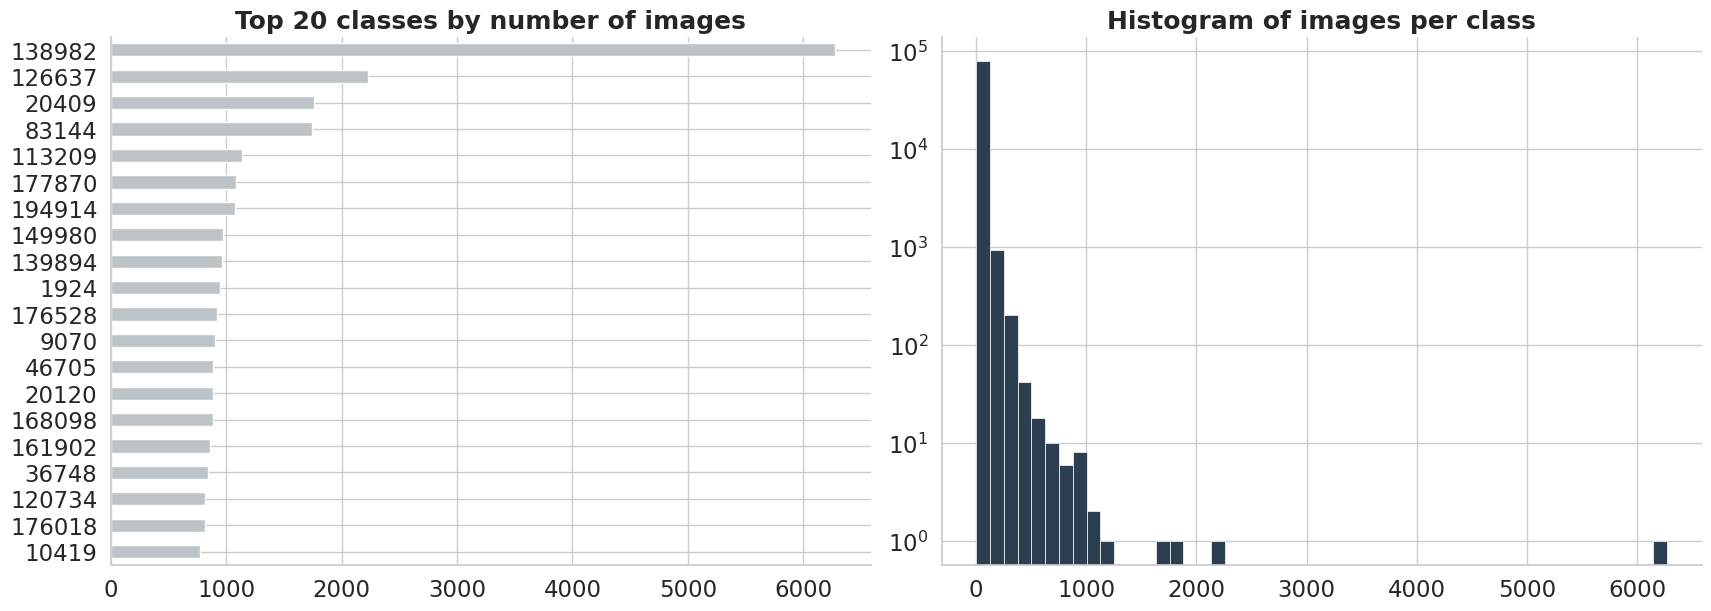

In [9]:
class_counts = train_df['landmark_id'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(17, 6), constrained_layout=True)

top20 = class_counts.head(20)

top20.sort_values().plot(kind='barh', ax=axes[0], color='#BDC3C7')
axes[0].set_title('Top 20 classes by number of images', fontweight='bold')
axes[0].yaxis.label.set_visible(False)

axes[1].hist(class_counts.values, bins=50, log=True,
             color='#2c3e50', edgecolor='white', linewidth=0.5)
axes[1].set_title('Histogram of images per class', fontweight='bold')

sns.despine()

plt.show()

In [6]:
def id_to_path(root: Path, img_id: str) -> Path:
    return root / img_id[0] / img_id[1] / img_id[2] / f"{img_id}.jpg"

In [7]:
def load_image(path: Path):
    try:
        img = Image.open(path)
        img = ImageOps.exif_transpose(img)
        return img.convert("RGB")
    except:
        return None

In [12]:
def show_random_images(df, root_dir: Path, n=5, max_cols=5):
    ids = random.sample(list(df['id']), n)

    loaded = []
    for img_id in ids:
        path = id_to_path(root_dir, img_id)
        img = load_image(path)
        loaded.append((img_id, img))

    n_images = len(loaded)

    ncols = min(max_cols, n_images)
    nrows = math.ceil(n_images / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3), squeeze=False)
    axes = axes.flatten()

    for idx, (img_id, img) in enumerate(loaded):
        ax = axes[idx]
        ax.imshow(img)
        ax.set_title(img_id, fontsize=9, pad=6)
        ax.axis('off')

    for ax in axes[n_images:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

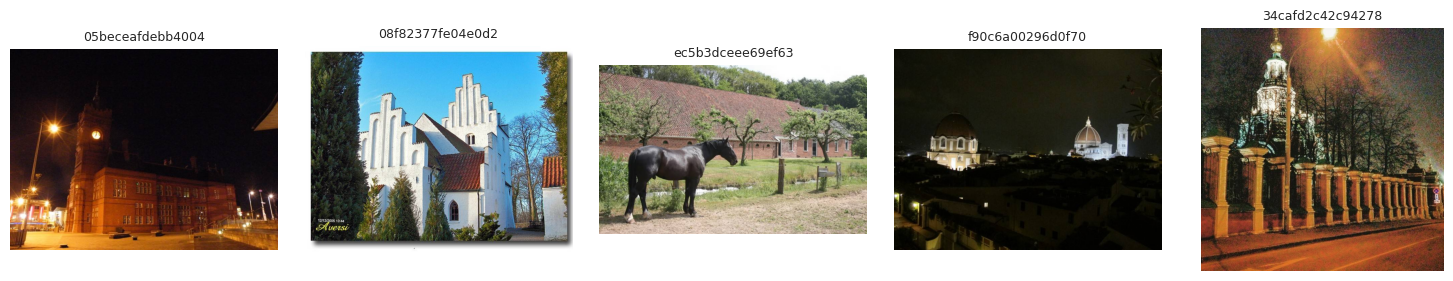

In [15]:
show_random_images(train_df, TRAIN_DIR, n=5)

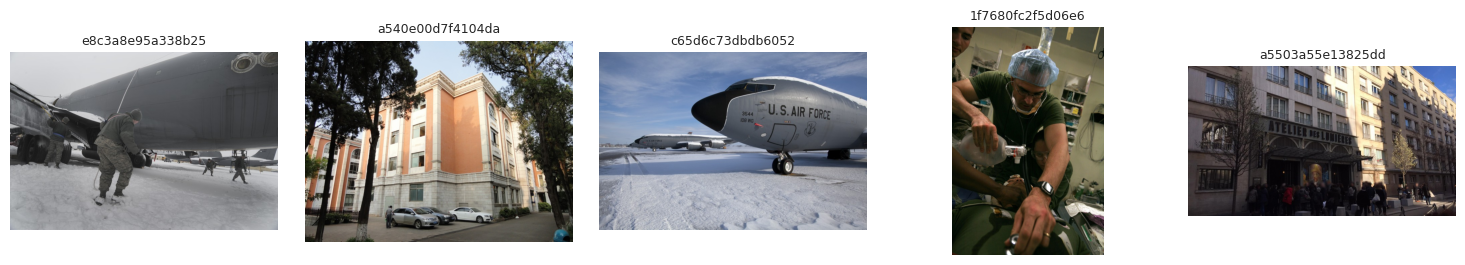

In [16]:
show_random_images(sub_df, TEST_DIR, n=5)

Распределение размеров изображений (случайная выборка 3000 из 1580470)


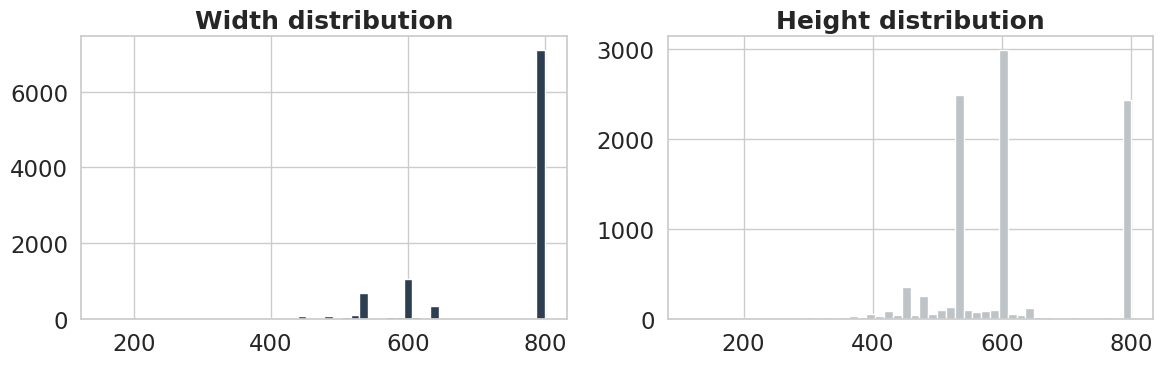

In [17]:
def get_image_size(img_id):
    path = id_to_path(TRAIN_DIR, img_id)
    img = load_image(path)
    return img.size if img else None

print(f"Распределение размеров изображений (случайная выборка 3000 из {len(train_df)})")

sample_ids = train_df["id"].sample(10000, random_state=42)

sizes = [get_image_size(i) for i in sample_ids]

widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=50, color='#2c3e50')
axes[0].set_title("Width distribution", fontweight='bold' )
axes[1].hist(heights, bins=50, color='#BDC3C7')
axes[1].set_title("Height distribution", fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
SAMPLE_SIZE = 10000
RANDOM_STATE = 42

random_ids = train_df['id'].sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE)

small_ids = []
for img_id in random_ids:
    with Image.open(id_to_path(TRAIN_DIR, img_id)) as img:
        w, h = img.size
        if w < 128 or h < 128:
            small_ids.append(img_id)

Отображение изображений с размером min(w, h) < 128


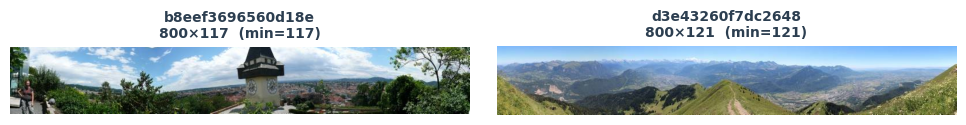

In [23]:
print("Отображение изображений с размером min(w, h) < 128")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

for ax, img_id in zip((ax1, ax2), small_ids):
    img = load_image(id_to_path(TRAIN_DIR, img_id))
    if img:
        w, h = img.size
        ax.imshow(img)
        ax.set_title(f'{img_id}\n{w}×{h}  (min={min(w,h)})', fontsize=10, fontweight='bold', color='#2c3e50')
    ax.axis('off')

plt.tight_layout()
plt.show()

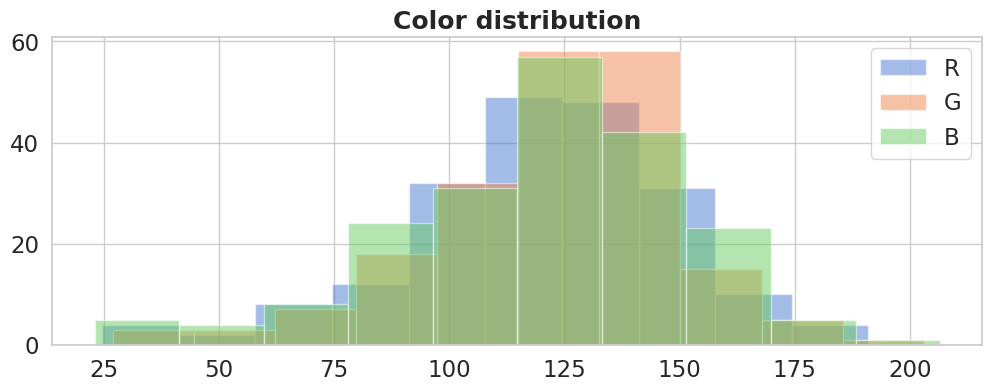

In [172]:
def mean_color(img):
    return np.array(img).mean(axis=(0,1))

colors = []
for img_id in sample_ids[:200]:
    img = load_image(id_to_path(TRAIN_DIR, img_id))
    if img:
        colors.append(mean_color(img))

colors = np.array(colors)

fig, axes = plt.subplots(1, figsize=(12, 4))
plt.hist(colors[:,0], alpha=0.5, label="R")
plt.hist(colors[:,1], alpha=0.5, label="G")
plt.hist(colors[:,2], alpha=0.5, label="B")
plt.legend()
plt.title("Color distribution", fontweight='bold')
plt.show()

In [27]:
def compute_saturation_stats(df, root_dir, id_col='id',
                             gray_thresh=5, desat_thresh=40,
                             sample=None, random_state=42):
    if sample is not None:
        ids = df[id_col].sample(n=min(sample, len(df)), random_state=random_state)
    else:
        ids = df[id_col]
    
    means = []
    labels = []
    errors = 0

    for img_id in tqdm(ids, desc="Computing saturation"):
        path = id_to_path(root_dir, str(img_id))
        img = load_image(path)
        if img is None:
            errors += 1
            continue
        
        hsv = img.convert("HSV")
        S = np.array(hsv)[:, :, 1]
        mean_S = np.mean(S)
        
        if mean_S < gray_thresh:
            lbl = "gray"
        elif mean_S < desat_thresh:
            lbl = "desaturated"
        else:
            lbl = "color"
        
        means.append(mean_S)
        labels.append(lbl)
    
    means = np.array(means)
    total = len(means)
    cnt = Counter(labels)
    
    stats = {
        'total': total,
        'gray_thresh': gray_thresh,
        'desat_thresh': desat_thresh,
        'gray_count': cnt['gray'],
        'desat_count': cnt['desaturated'],
        'color_count': cnt['color'],
    }
    
    print(f"Успешно обработано: {total} изображений")
    print(f"Полностью чёрно-белые: {stats['gray_count']:5d}  ({100 * stats['gray_count'] / total:.1f}%)")
    print(f"Сильно обесцвеченные: {stats['desat_count']:5d}  ({100 * stats['desat_count'] / total:.1f}%)")
    print(f"Полноцветные: {stats['color_count']:5d}  ({100 * stats['color_count'] / total:.1f}%)")
    print(f"Суммарно обесцвеченных: {stats['gray_count'] + stats['desat_count']:5d}  ({100 * (stats['gray_count'] + stats['desat_count']) / total:.1f}%)")
    
    return means, labels, stats

In [30]:
means, labels, stats = compute_saturation_stats(
    train_df, TRAIN_DIR, id_col='id',
    gray_thresh=5, desat_thresh=40,
    sample=5000
)

Computing saturation: 100%|██████████| 5000/5000 [01:29<00:00, 55.60it/s]

Успешно обработано: 5000 изображений
Полностью чёрно-белые:   144  (2.9%)
Сильно обесцвеченные:   751  (15.0%)
Полноцветные:  4105  (82.1%)
Суммарно обесцвеченных:   895  (17.9%)


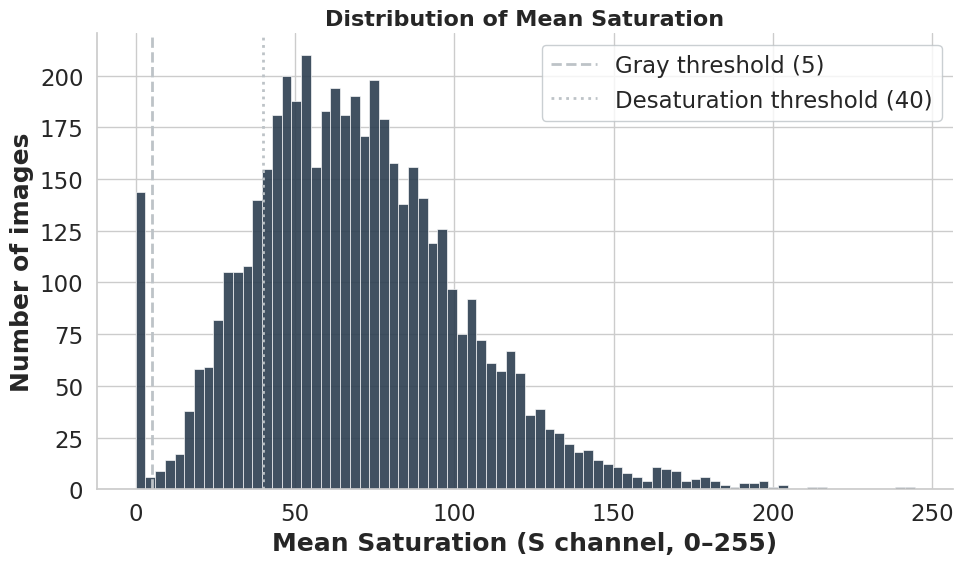

In [37]:
gray_thresh = stats['gray_thresh']
desat_thresh = stats['desat_thresh']

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(means, bins=80, color='#2c3e50', edgecolor='white', linewidth=0.5, alpha=0.9)

ax.axvline(gray_thresh, color='#BDC3C7', linestyle='--', linewidth=2, 
           label=f'Gray threshold ({gray_thresh})')
ax.axvline(desat_thresh, color='#BDC3C7', linestyle=':', linewidth=2, 
           label=f'Desaturation threshold ({desat_thresh})')

ax.set_title('Distribution of Mean Saturation', fontweight='bold', fontsize=16)
ax.set_xlabel('Mean Saturation (S channel, 0–255)', fontweight='bold')
ax.set_ylabel('Number of images', fontweight='bold')
ax.legend(frameon=True, facecolor='white', edgecolor='#BDC3C7')
sns.despine()
plt.tight_layout()
plt.show()

In [40]:
def show_landmark(df, root_dir: Path, landmark_id, num=6):
    subset = df[df["landmark_id"] == landmark_id]

    num = min(num, len(subset))
    sample = subset.sample(num)

    fig, axes = plt.subplots(1, num, figsize=(3 * num, 3))
    if num == 1:
        axes = [axes]

    for i, row in enumerate(sample.itertuples()):
        img = load_image(id_to_path(root_dir, row.id))
        if img:
            axes[i].imshow(img)
        axes[i].axis('off')

    fig.suptitle(f'Landmark ID: {landmark_id} ({len(subset)} images total)', 
                 fontweight='bold', fontsize=14, color='#2c3e50')
    sns.despine()
    plt.tight_layout()
    plt.show()

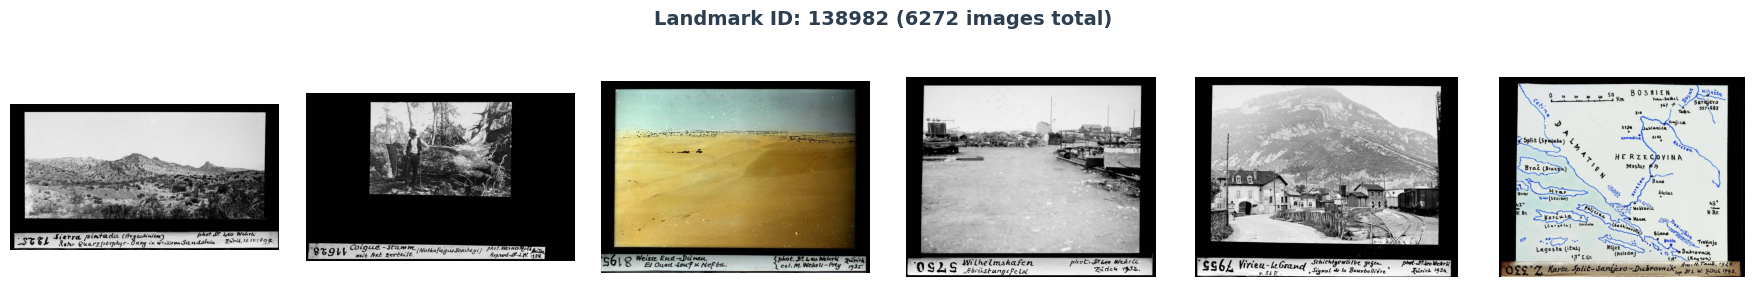

In [41]:
example_landmark = counts.index[0]
show_landmark(train_df, TRAIN_DIR, example_landmark)

100%|██████████| 500/500 [00:15<00:00, 32.77it/s]


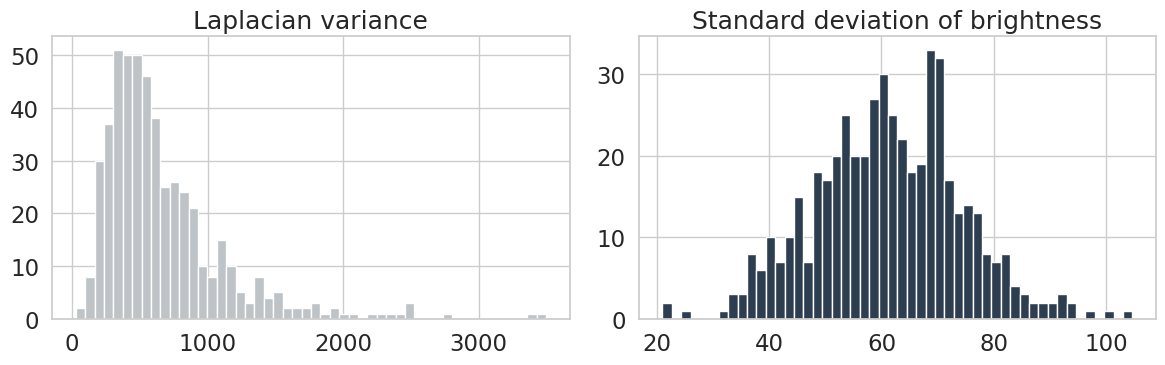

Самое размытое изображение: fceef316f332d251, score=27.89


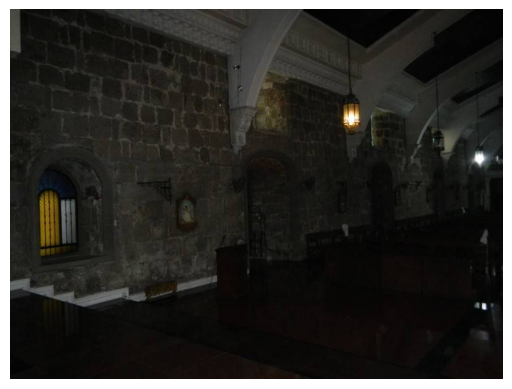

In [10]:
def blur_score(image):
    gray = image.convert('L')
    laplacian_kernel = ImageFilter.Kernel(
        (3, 3), [0, 1, 0, 1, -4, 1, 0, 1, 0], scale=1, offset=0
    )
    filtered = gray.filter(laplacian_kernel)
    arr = np.array(filtered)
    return arr.var()

def contrast_score(image):
    gray = image.convert('L')
    arr = np.array(gray)
    return arr.std()

sample = train_df['id'].sample(500, random_state=42)
blur_scores = []
contrast_scores = []
for img_id in tqdm(sample):
    img = load_image(id_to_path(TRAIN_DIR, img_id))
    if img:
        blur_scores.append(blur_score(img))
        contrast_scores.append(contrast_score(img))

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].hist(blur_scores, bins=50, color='#BDC3C7')
axes[0].set_title('Laplacian variance')
axes[1].hist(contrast_scores, bins=50, color='#2c3e50')
axes[1].set_title('Standard deviation of brightness')
plt.tight_layout()
plt.show()

idx = np.argmin(blur_scores)
blurred_id = sample.iloc[idx]
plt.imshow(load_image(id_to_path(TRAIN_DIR, blurred_id)))
print(f"Самое размытое изображение: {blurred_id}, score={blur_scores[idx]:.2f}")
plt.axis('off')
plt.show()